### ***Todo***

In [ ]:
import numpy as np
import pandas as pd
import re
from dataclasses import dataclass
from typing import Tuple, Optional, Dict, Literal
from sklearn.decomposition import PCA
from IPython.display import display
from google.colab import files


In [ ]:
# ---------- Utilidades de sanitización ----------
_SAN_RE = re.compile(r"[^A-Za-z0-9_]+")

def _sanitize_ticker(col: str) -> str:
    tok = col.split(" ")[0]
    tok = tok.replace("/", "_").replace(".", "_")
    tok = _SAN_RE.sub("", tok)
    return tok

def _dedupe(names: list[str]) -> list[str]:
    seen = {}
    out = []
    for n in names:
        k = n.lower()
        seen[k] = seen.get(k, 0) + 1
        out.append(n if seen[k] == 1 else f"{n}_{seen[k]-1}")
    return out

# ---------- Carga del Excel ----------
def load_spx_excel_prices(
    xlsx_path: str,
    sheet: str = "Worksheet",
    engine: Optional[str] = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    raw = pd.read_excel(xlsx_path, sheet_name=sheet, engine=engine)

    # 1) Fecha
    date_col = raw.columns[0]
    raw = raw.rename(columns={date_col: "date"})
    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    raw = raw.dropna(subset=["date"])

    # 2) Mapeo de columnas
    original_cols = list(raw.columns[1:])
    sanitized = [_sanitize_ticker(c) for c in original_cols]
    sanitized = _dedupe(sanitized)

    exchanges = []
    for col in original_cols:
        parts = str(col).split(" ")
        exch = parts[1] if len(parts) >= 2 else None  # UN / UW / etc.
        exchanges.append(exch)

    colmap = dict(zip(original_cols, sanitized))

    # 3) Dataframe ancho de precios
    prices_wide = (
        raw.rename(columns=colmap)
           .set_index("date")
           .apply(pd.to_numeric, errors="coerce")
    )
    prices_wide = prices_wide[~prices_wide.index.duplicated(keep="first")].sort_index()

    # 4) Meta (alineada por posición)
    asset_meta = pd.DataFrame({
        "asset": sanitized,
        "exchange": exchanges,
        "original_name": original_cols
    })

    return prices_wide, asset_meta

# ---------- Notificación y preview ----------
def notify_and_preview(prices_wide: pd.DataFrame,
                       show_preview: bool = True,
                       n_rows: int = 5,
                       n_assets: int = 6) -> None:

    n_days, n_assets_total = prices_wide.shape
    date_min = prices_wide.index.min().date() if n_days else "N/A"
    date_max = prices_wide.index.max().date() if n_days else "N/A"
    print(f"✓ Base de datos limpia creada: {n_days} días × {n_assets_total} activos "
          f"({date_min} → {date_max}).")

    if show_preview and n_days and n_assets_total:
        print("\nPreview (primeras filas × primeros activos):")
        print(prices_wide.iloc[:n_rows, :n_assets])


In [ ]:
# ---------------- Config ----------------
@dataclass
class PreprocessConfig:
    max_na_frac_per_asset: float = 0.05
    winsorize_pct: float = 0.01
    min_trading_days: int = 750
    explained_var_threshold: float = 0.80
    # Opciones extra
    min_var_tol: float = 1e-8
    fill_strategy: Optional[Literal["ffill","bfill","ffill_bfill"]] = None
    svd_solver: Literal["auto","full","randomized"] = "auto"
    randomized_iter: int = 4
    random_state: Optional[int] = 42

# ---------------- Utilidades ----------------
def _safe_log(prices: pd.DataFrame) -> pd.DataFrame:
    p = prices.mask(~(prices > 0))
    return np.log(p)

def log_returns(prices_wide: pd.DataFrame) -> pd.DataFrame:
    return _safe_log(prices_wide).diff()

def winsorize_per_asset(returns: pd.DataFrame, pct: float) -> pd.DataFrame:
    if pct <= 0:
        return returns
    q_low = returns.quantile(pct)
    q_high = returns.quantile(1 - pct)
    return returns.clip(lower=q_low, upper=q_high, axis=1)

def zscore_per_asset(returns: pd.DataFrame) -> pd.DataFrame:
    mean = returns.mean(skipna=True)
    std = returns.std(ddof=1, skipna=True).replace(0.0, np.nan)
    return (returns - mean) / std

def filter_assets_by_na_and_length(returns: pd.DataFrame,
                                   max_na_frac: float,
                                   min_days: int,
                                   min_var_tol: float = 0.0) -> pd.DataFrame:
    keep = []
    for col in returns.columns:
        s = returns[col]
        if s.isna().mean() <= max_na_frac and s.notna().sum() >= min_days:
            if min_var_tol > 0:
                v = s.var(skipna=True)
                if pd.isna(v) or v < min_var_tol:
                    continue
            keep.append(col)
    return returns[keep]

# ---------------- Resultados PCA ----------------
@dataclass
class PCAResult:
    loadings: pd.DataFrame
    embeddings: pd.DataFrame
    explained_var_ratio: np.ndarray
    components_scores: pd.DataFrame
    k: int

# ---------------- PCA core ----------------
def compute_asset_embeddings_via_pca(returns_z: pd.DataFrame,
                                     explained_var_threshold: float = 0.90,
                                     svd_solver: str = "auto",
                                     randomized_iter: int = 4,
                                     random_state: Optional[int] = 42,
                                     fill_strategy: Optional[str] = None) -> PCAResult:
    R = returns_z.copy()
    if fill_strategy in ("ffill","ffill_bfill"):
        R = R.ffill()
    if fill_strategy in ("bfill","ffill_bfill"):
        R = R.bfill()

    Rn = R.dropna(how="any")
    if Rn.empty:
        raise ValueError("No quedan filas completas para PCA")

    pca_full = PCA(n_components=min(Rn.shape), svd_solver=svd_solver,
                   iterated_power=randomized_iter if svd_solver=="randomized" else "auto",
                   random_state=random_state)
    pca_full.fit(Rn.values)
    cumexp_full = np.cumsum(pca_full.explained_variance_ratio_)

    k = int(np.searchsorted(cumexp_full, explained_var_threshold) + 1)
    k = max(1, min(k, Rn.shape[1]))

    pca = PCA(n_components=k, svd_solver=svd_solver,
              iterated_power=randomized_iter if svd_solver=="randomized" else "auto",
              random_state=random_state)
    PCs = pca.fit_transform(Rn.values)
    evr_k = pca.explained_variance_ratio_

    loadings = pd.DataFrame(pca.components_, index=[f"PC{i+1}" for i in range(k)], columns=Rn.columns)
    embeddings = loadings.T.copy()
    embeddings.index.name = "asset"
    components_scores = pd.DataFrame(PCs, index=Rn.index, columns=[f"PC{i+1}" for i in range(k)])

    res = PCAResult(loadings=loadings, embeddings=embeddings,
                    explained_var_ratio=evr_k, components_scores=components_scores, k=k)
    res._cumexp_full = cumexp_full
    res._n_obs = Rn.shape[0]
    res._n_assets = Rn.shape[1]
    return res

# ---------------- Pipeline completo ----------------
def build_pca_embedding_from_prices(prices_wide: pd.DataFrame,
                                    cfg: Optional[PreprocessConfig] = None) -> Tuple[pd.DataFrame, Dict]:
    cfg = cfg or PreprocessConfig()

    rets = log_returns(prices_wide)
    rets_w = winsorize_per_asset(rets, cfg.winsorize_pct)
    rets_f = filter_assets_by_na_and_length(rets_w, cfg.max_na_frac_per_asset,
                                            cfg.min_trading_days, cfg.min_var_tol)
    rets_z = zscore_per_asset(rets_f)

    pca_res = compute_asset_embeddings_via_pca(rets_z,
                                               explained_var_threshold=cfg.explained_var_threshold,
                                               svd_solver=cfg.svd_solver,
                                               randomized_iter=cfg.randomized_iter,
                                               random_state=cfg.random_state,
                                               fill_strategy=cfg.fill_strategy)

    cumexp_full = getattr(pca_res, "_cumexp_full", np.cumsum(pca_res.explained_var_ratio))
    meta = {
        "kept_assets": list(pca_res.embeddings.index),
        "k": pca_res.k,
        "explained_var_ratio": pca_res.explained_var_ratio.tolist(),
        "cumulative_explained_var_ratio": cumexp_full.tolist(),
        "n_observations_for_pca": getattr(pca_res, "_n_obs", None),
        "n_assets_for_pca": getattr(pca_res, "_n_assets", None),
    }
    return pca_res.embeddings, meta


In [ ]:
# Subir Excel
uploaded = files.upload()
xlsx_file = list(uploaded.keys())[0]

# Cargar precios y meta
datos, asset_meta = load_spx_excel_prices(xlsx_file, sheet="Worksheet")
notify_and_preview(datos, show_preview=True, n_rows=8, n_assets=8)

# Configuración PCA
cfg = PreprocessConfig(
    max_na_frac_per_asset=0.05,
    winsorize_pct=0.01,
    min_trading_days=750,
    explained_var_threshold=0.80,
    random_state=42,
    min_var_tol=1e-10,
    fill_strategy=None,
    svd_solver="auto"
)

# Ejecutar PCA
embeddings, meta = build_pca_embedding_from_prices(datos, cfg)

# Mostrar resultados
print("\n=== PCA SUMMARY ===")
print("Rows × Cols (prices):", datos.shape)
print("Filtrado -> n_obs × n_assets:", meta["n_observations_for_pca"], "×", meta["n_assets_for_pca"])
print("Assets kept:", len(meta["kept_assets"]))
print("k (PCs):", meta["k"])
print("Cumulative explained variance:", round(meta["cumulative_explained_var_ratio"][meta['k'] - 1], 4))

print("\nEmbeddings (head):")
display(embeddings.head())


Saving datos.xlsx to datos.xlsx
✓ Base de datos limpia creada: 1326 días × 503 activos (2020-07-09 → 2025-08-07).

Preview (primeras filas × primeros activos):
               ZTS    ZBRA       ZBH    YUM     XYZ    XYL    XOM    XEL
date                                                                    
2020-07-09  158.88  283.04  135.2157  90.82  147.22  77.15  43.44  72.34
2020-07-10  156.93  280.57  134.0807  92.70  138.25  80.30  44.97  70.52
2020-07-13  159.36  284.01  134.4396  93.16  139.02  80.10  44.09  71.48
2020-07-14  158.87  285.61  133.7897  92.77  143.19  79.48  43.01  71.28
2020-07-15  157.05  286.03  133.2173  92.65  141.96  79.62  43.20  70.73
2020-07-16  157.42  286.74  134.4396  93.60  152.48  79.22  42.64  70.20
2020-07-17  160.17  281.96  134.6531  94.90  151.04  79.33  42.43  70.00
2020-07-20  158.58  283.13  133.1494  93.93  150.37  79.38  41.96  69.58

=== PCA SUMMARY ===
Rows × Cols (prices): (1326, 503)
Filtrado -> n_obs × n_assets: 1265 × 479
Assets kept: 4

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102
asset,,,,,,,,,,,,,,,,,,,,,
ZTS,0.045823,0.015409,-0.077061,-0.002371,-0.006741,0.055962,-0.052456,-0.049116,0.035193,0.005434,...,-0.025898,0.012596,0.061228,-0.110247,0.015078,-0.005451,0.024537,-0.009518,-0.026585,0.001028
ZBRA,0.055626,-0.050466,-0.029045,-0.027946,0.024498,0.006028,0.022858,0.014091,0.016812,-0.030616,...,-0.006612,-0.108915,-0.098638,0.034485,-0.046468,0.017150,-0.063483,-0.021385,-0.053906,0.070754
ZBH,0.045801,0.019094,-0.004362,-0.003543,-0.009533,0.012976,-0.090153,0.004316,0.010164,0.067089,...,0.045652,-0.032806,-0.045732,0.001527,-0.008683,0.098650,-0.038930,0.011171,0.022523,-0.018450
YUM,0.046270,0.026604,-0.027510,0.021508,-0.030874,-0.001328,-0.027588,0.000935,-0.069436,0.048489,...,0.048956,-0.066637,0.034059,0.038287,0.054889,-0.003403,0.066343,0.084584,-0.049038,-0.079749
XYZ,0.047266,-0.062569,-0.051783,-0.001859,0.051803,-0.017499,-0.070056,-0.023233,-0.017536,-0.083893,...,-0.010267,0.057622,-0.028035,0.010051,0.037090,-0.020162,-0.050765,-0.014164,-0.046650,0.009281


In [ ]:
import numpy as np
import pandas as pd
from typing import Tuple, Dict, Optional, Iterable
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import silhouette_score
from math import ceil, log2
from IPython.display import display

# =========================
# Helpers de vista (paginado y miembros)
# =========================
def print_dataframe_paginated(df: pd.DataFrame, page_rows: int = 200) -> None:
    """
    En Colab no usamos input() para pausar.
    Se muestran los datos por bloques secuenciales.
    """
    n = df.shape[0]
    for start in range(0, n, page_rows):
        end = min(start + page_rows, n)
        chunk = df.iloc[start:end]
        print(f"\n--- Filas {start+1}–{end} de {n} ---")
        with pd.option_context(
            "display.max_rows", None,
            "display.max_columns", None,
            "display.width", 0,
            "display.expand_frame_repr", False
        ):
            display(chunk)

def show_cluster_members(labels_df: pd.DataFrame,
                         include_noise: bool = False,
                         max_rows_per_cluster: Optional[int] = None) -> None:
    """
    Muestra solo el 'asset' por clúster.
    - include_noise: si True también lista el clúster -1 (ruido)
    """
    labs = labels_df.copy()
    labs = labs.reset_index().rename(columns={"index": "asset"}) if labs.index.name != "asset" else labs.reset_index()

    if not include_noise:
        labs = labs[labs["cluster"] >= 0]

    if labs.empty:
        print("No hay clústeres para mostrar (quizás todo es ruido).")
        return

    for c, grp in labs.sort_values(["cluster", "asset"]).groupby("cluster"):
        print(f"\n== Cluster {c} (n={len(grp)}) ==")
        tabla = grp[["asset"]].reset_index(drop=True)
        if max_rows_per_cluster is not None and len(tabla) > max_rows_per_cluster:
            print(tabla.head(max_rows_per_cluster).to_string(index=False))
            print(f"... ({len(tabla) - max_rows_per_cluster} más)")
        else:
            print_dataframe_paginated(tabla, page_rows=200)

# =========================
# Helpers de preparación
# =========================
def _select_first_m_pcs(embeddings: pd.DataFrame, m_pcs: Optional[int]) -> pd.DataFrame:
    if m_pcs is None:
        return embeddings
    cols = [c for c in embeddings.columns if c.startswith("PC")]
    cols_sorted = sorted(cols, key=lambda x: int(x[2:]))
    return embeddings[cols_sorted[:min(m_pcs, len(cols_sorted))]].copy()

def prepare_features(embeddings: pd.DataFrame,
                     scale: bool = True,
                     l2_row_norm: bool = True,
                     m_pcs: Optional[int] = 12) -> Tuple[np.ndarray, np.ndarray]:
    """
    Selecciona primeros m_pcs, estandariza columnas y normaliza cada fila a norma L2=1.
    Esto estabiliza DBSCAN/OPTICS en alta dimensión.
    """
    emb = _select_first_m_pcs(embeddings, m_pcs)
    X = emb.values.astype(float)
    if scale:
        X = StandardScaler().fit_transform(X)
    if l2_row_norm:
        X = normalize(X, norm="l2", axis=1)
    assets = emb.index.to_numpy()
    return X, assets

def infer_eps_kdist(X: np.ndarray, k: int) -> np.ndarray:
    """
    Vector ordenado de distancias al k-ésimo vecino (k-dist).
    Útil para diagnosticar rangos razonables de eps.
    """
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    kdist = np.sort(distances[:, -1])
    return kdist

# =========================
# Algoritmos de clustering
# =========================
def _try_dbscan_with_quantile(X: np.ndarray, min_samples: int, q: float):
    kdist = infer_eps_kdist(X, k=min_samples)
    eps = float(np.quantile(kdist, q))
    model = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
    labels = model.fit_predict(X)
    return labels, eps

def run_dbscan(embeddings: pd.DataFrame,
               min_samples: int = 6,
               eps: Optional[float] = None,
               quantiles: Iterable[float] = (0.60, 0.65, 0.70, 0.75, 0.80, 0.85),
               scale: bool = True,
               l2_row_norm: bool = True,
               m_pcs: Optional[int] = 12) -> Tuple[pd.DataFrame, Dict]:
    """
    DBSCAN robusto:
      - Usa primeros m_pcs (default 12).
      - Si eps=None, prueba varios cuantiles y elige por silhouette.
    """
    X, assets = prepare_features(embeddings, scale=scale, l2_row_norm=l2_row_norm, m_pcs=m_pcs)

    tried = []
    if eps is None:
        best = {"score": -1.0, "labels": None, "eps": None, "ncl": 0}
        for q in quantiles:
            labels, eps_q = _try_dbscan_with_quantile(X, min_samples, q)
            n_clusters = len({c for c in labels if c >= 0})
            mask = labels >= 0
            sil = None
            if mask.any() and len(np.unique(labels[mask])) >= 2:
                sil = silhouette_score(X[mask], labels[mask], metric="euclidean")
                score = sil
            else:
                score = 0.0 if 2 <= n_clusters <= 30 else -1.0
            tried.append((q, eps_q, n_clusters, sil))
            if score > best["score"]:
                best = {"score": score, "labels": labels, "eps": eps_q, "ncl": n_clusters}
        labels = best["labels"]
        eps = best["eps"]
    else:
        model = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
        labels = model.fit_predict(X)

    labels_df = pd.DataFrame({"asset": assets, "cluster": labels}).set_index("asset")
    params = {
        "eps": float(eps),
        "min_samples": min_samples,
        "scale": scale,
        "l2_row_norm": l2_row_norm,
        "m_pcs": m_pcs,
        "tried": tried
    }
    return labels_df, params

def run_optics(embeddings: pd.DataFrame,
               min_samples: Optional[int] = None,
               xi: float = 0.05,
               min_cluster_size: Optional[int] = None,
               scale: bool = True,
               l2_row_norm: bool = True,
               m_pcs: Optional[int] = 12) -> Tuple[pd.DataFrame, Dict]:
    """
    OPTICS con la misma preparación de features.
    """
    emb = _select_first_m_pcs(embeddings, m_pcs)
    N = emb.shape[0]
    if min_samples is None:
        min_samples = max(5, ceil(log2(max(10, N))))
    if min_cluster_size is None:
        min_cluster_size = max(5, int(0.02 * N))

    X, assets = prepare_features(embeddings, scale=scale, l2_row_norm=l2_row_norm, m_pcs=m_pcs)
    model = OPTICS(min_samples=min_samples, xi=xi, min_cluster_size=min_cluster_size)
    labels = model.fit_predict(X)
    labels_df = pd.DataFrame({"asset": assets, "cluster": labels}).set_index("asset")
    params = {
        "min_samples": min_samples, "xi": xi, "min_cluster_size": min_cluster_size,
        "scale": scale, "l2_row_norm": l2_row_norm, "m_pcs": m_pcs
    }
    return labels_df, params

# =========================
# Utilidades de evaluación
# =========================
def cluster_quality(embeddings: pd.DataFrame, labels_df: pd.DataFrame, m_pcs: Optional[int] = 12) -> Dict:
    emb = _select_first_m_pcs(embeddings, m_pcs)
    X = emb.values.astype(float)
    labels = labels_df["cluster"].to_numpy()
    sil = None
    mask = labels >= 0
    uniq = np.unique(labels[mask])
    if mask.any() and len(uniq) >= 2:
        sil = silhouette_score(X[mask], labels[mask], metric="euclidean")
    sizes = labels_df[labels_df["cluster"] >= 0]["cluster"].value_counts().sort_index().to_dict()
    noise_frac = float((labels < 0).mean())
    n_clusters = len(sizes)
    return {"silhouette": sil, "cluster_sizes": sizes, "noise_fraction": noise_frac, "n_clusters": n_clusters}


In [ ]:
# 1) DBSCAN robusto
labels_db, params_db = run_dbscan(embeddings, min_samples=6, eps=None, m_pcs=12)
print("\n--- DBSCAN params ---")
print(params_db)

# 2) Calidad de clustering
q = cluster_quality(embeddings, labels_db, m_pcs=12)
print("\n--- Cluster quality ---")
print(q)

print("\n--- Cluster sizes (incl. noise=-1) ---")
print(labels_db["cluster"].value_counts().sort_index())

# 3) Mostrar acciones por clúster
print("\n--- Miembros por clúster (solo asset) ---")
show_cluster_members(labels_df=labels_db, include_noise=False, max_rows_per_cluster=10)





--- DBSCAN params ---
{'eps': 0.6054343375372345, 'min_samples': 6, 'scale': True, 'l2_row_norm': True, 'm_pcs': 12, 'tried': [(0.6, 0.6054343375372345, 10, np.float64(0.30876357323452425)), (0.65, 0.6336974561171694, 10, np.float64(0.1584740110808618)), (0.7, 0.6592060179603102, 10, np.float64(0.14661374196315538)), (0.75, 0.692854491753311, 5, np.float64(0.0010873957446090553)), (0.8, 0.7163172015195131, 4, np.float64(0.03760696554510712)), (0.85, 0.7423057480569749, 3, np.float64(0.08636783145424655))]}

--- Cluster quality ---
{'silhouette': np.float64(0.28792255513925535), 'cluster_sizes': {0: 65, 1: 25, 2: 27, 3: 25, 4: 99, 5: 42, 6: 22, 7: 32, 8: 21, 9: 6}, 'noise_fraction': 0.24008350730688935, 'n_clusters': 10}

--- Cluster sizes (incl. noise=-1) ---
cluster
-1    115
 0     65
 1     25
 2     27
 3     25
 4     99
 5     42
 6     22
 7     32
 8     21
 9      6
Name: count, dtype: int64

--- Miembros por clúster (solo asset) ---

== Cluster 0 (n=65) ==
asset
 ALLE
  AME


,asset
0,GD
1,HII
2,LDOS
3,LHX
4,LMT
5,NOC


✓ Precios cargados: 1326 días × 503 activos


Ventanas: 100%|██████████| 52/52 [23:35<00:00, 27.22s/win]



Ventanas calculadas: 52
Última ventana: 2024-08-19 → 2025-08-05
PCs retenidos: 31
Calidad: {'silhouette': np.float64(0.4210840638424162), 'cluster_sizes': {0: 21, 1: 9, 2: 35, 3: 22, 4: 19, 5: 16, 6: 13, 7: 13}, 'noise_fraction': 0.7034068136272545, 'n_clusters': 8}


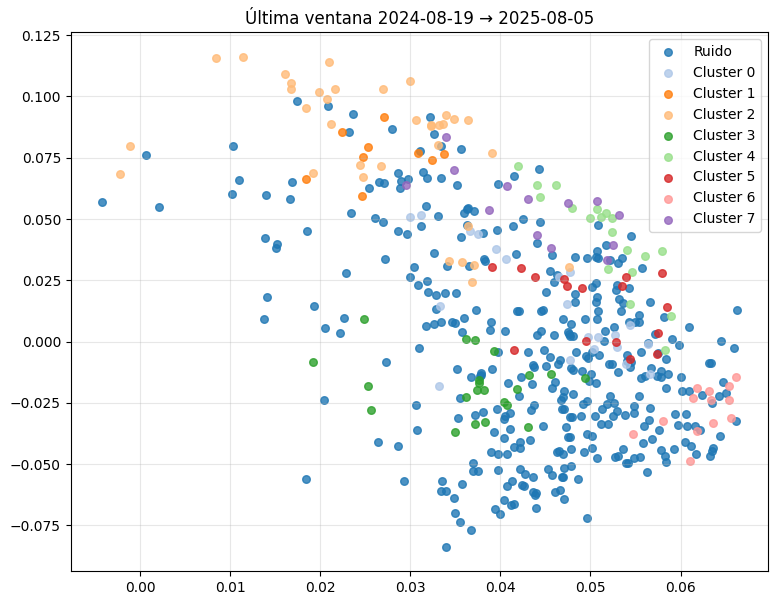

In [ ]:
# ============================================================
# Rolling PCA + Clustering (DBSCAN/OPTICS) en Colab
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import time

try:
    from tqdm import tqdm
    _TQDM = True
except ImportError:
    _TQDM = False

try:
    import mplcursors
    MPLCURSORS_OK = True
except ImportError:
    MPLCURSORS_OK = False

# ================== Configuración ==================
DATA_XLSX = "datos.xlsx"
SHEET     = "Worksheet"

ROLL_WIN   = 252   # ~1 año de trading
ROLL_STEP  = 21    # ~1 mes

# PCA
EXPL_VAR_TARGET = 0.70
WINSOR_PCT      = 0.01
MAX_NA_FRAC     = 0.10
MIN_DAYS_FRAC   = 0.90
MIN_VAR_TOL     = 1e-10
FILL_STRATEGY   = "ffill_bfill"
SVD_SOLVER      = "auto"
RANDOM_STATE    = 42

# Clustering
USE_ALGO        = "OPTICS"  # también puedes probar "DBSCAN"
M_PCS_CLUST     = 12
DBSCAN_MIN_SAMPLES = 6
DBSCAN_QUANTILES   = (0.60, 0.65, 0.70, 0.75, 0.80, 0.85)

# Estabilidad
STABILITY_THRESH = 0.60

# Visualización
SHOW_SCATTER = True
SHOW_HEATMAP = True
MAX_ASSETS_HEATMAP = 60

# ---------------- Estructuras ----------------
@dataclass
class WindowResult:
    start: pd.Timestamp
    end: pd.Timestamp
    labels: pd.Series
    cluster_members: Dict[int, List[str]]
    quality: Dict
    pca_k: int
    pca_evr: np.ndarray
    embeddings: pd.DataFrame

# ---------------- Helpers ----------------
def _rolling_indices(idx_dates, roll_win: int, roll_step: int):
    out = []
    n = len(idx_dates)
    for start in range(0, max(1, n - roll_win + 1), roll_step):
        end = start + roll_win
        if end > n:
            break
        out.append((start, end))
    return out

def pca_embeddings_for_window(rets_window: pd.DataFrame):
    # Winsorize
    Rw = winsorize_per_asset(rets_window, WINSOR_PCT)
    min_days_win = max(30, int(MIN_DAYS_FRAC * Rw.shape[0]))

    Rf = filter_assets_by_na_and_length(
        Rw, max_na_frac=MAX_NA_FRAC, min_days=min_days_win, min_var_tol=MIN_VAR_TOL
    )
    if Rf.shape[1] < 5:
        return None, None

    Rz = zscore_per_asset(Rf)
    try:
        pca_res = compute_asset_embeddings_via_pca(
            Rz,
            explained_var_threshold=EXPL_VAR_TARGET,
            svd_solver=SVD_SOLVER,
            randomized_iter=4,
            random_state=RANDOM_STATE,
            fill_strategy=FILL_STRATEGY
        )
        return pca_res.embeddings, {"k": pca_res.k, "evr": pca_res.explained_var_ratio}
    except Exception:
        return None, None

def cluster_one_window(embeddings: pd.DataFrame):
    if USE_ALGO.upper() == "DBSCAN":
        labels_df, _ = run_dbscan(embeddings, min_samples=DBSCAN_MIN_SAMPLES,
                                  eps=None, quantiles=DBSCAN_QUANTILES,
                                  m_pcs=M_PCS_CLUST)
    else:
        labels_df, _ = run_optics(embeddings, m_pcs=M_PCS_CLUST)
    return labels_df

# ---------------- Rolling secuencial ----------------
def build_windows_sequential(prices: pd.DataFrame):
    rets = log_returns(prices).dropna(how="all")
    idx_dates = rets.index
    tickers_all = rets.columns.tolist()

    windows: List[WindowResult] = []
    stability = pd.DataFrame(0.0, index=tickers_all, columns=tickers_all)
    counts    = pd.DataFrame(0.0, index=tickers_all, columns=tickers_all)

    win_ranges = _rolling_indices(idx_dates, ROLL_WIN, ROLL_STEP)
    pbar = tqdm(total=len(win_ranges), desc="Ventanas", unit="win") if _TQDM else None

    for (start, end) in win_ranges:
        seg = rets.iloc[start:end].dropna(axis=1, how="all")
        if seg.shape[1] < 5:
            if pbar: pbar.update(1)
            continue

        emb, meta = pca_embeddings_for_window(seg)
        if emb is None:
            if pbar: pbar.update(1)
            continue

        labels_df = cluster_one_window(emb)
        quality = cluster_quality(emb, labels_df, m_pcs=M_PCS_CLUST)
        cluster_members = {c: sorted(labels_df.index[labels_df["cluster"] == c].tolist())
                           for c in sorted([c for c in labels_df["cluster"].unique() if c >= 0])}

        windows.append(WindowResult(
            start=seg.index[0], end=seg.index[-1],
            labels=labels_df["cluster"].copy(),
            cluster_members=cluster_members,
            quality=quality,
            pca_k=meta["k"], pca_evr=meta["evr"],
            embeddings=emb
        ))

        # actualizar matriz de estabilidad
        for c, members in cluster_members.items():
            for i in range(len(members)):
                a = members[i]
                for j in range(i, len(members)):
                    b = members[j]
                    stability.loc[a, b] += 1.0
                    stability.loc[b, a] += 1.0
        present = labels_df.index.tolist()
        for a in present:
            for b in present:
                counts.loc[a, b] += 1.0

        if pbar: pbar.update(1)

    if pbar: pbar.close()

    with np.errstate(divide="ignore", invalid="ignore"):
        stability = stability / counts.replace(0.0, np.nan)
    stability = stability.fillna(0.0)
    return windows, stability

# ---------------- Visualización ----------------
def plot_last_window_scatter(last: WindowResult):
    emb = last.embeddings
    if emb.shape[1] < 2:
        print("No hay suficientes PCs para el scatter.")
        return
    x, y = emb.iloc[:, 0], emb.iloc[:, 1]
    labels = last.labels.reindex(emb.index)
    uniq = sorted(labels.unique())
    cmap = plt.get_cmap("tab20")
    plt.figure(figsize=(9, 7))
    for i, c in enumerate(uniq):
        idx = labels[labels == c].index
        plt.scatter(x.loc[idx], y.loc[idx], s=30,
                    label=f"Cluster {c}" if c != -1 else "Ruido",
                    alpha=0.8, c=[cmap(i % 20)])
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.title(f"Última ventana {last.start.date()} → {last.end.date()}")
    if MPLCURSORS_OK:
        mplcursors.cursor(hover=True)
    plt.show()

# ---------------- Main ----------------
prices_wide, asset_meta = load_spx_excel_prices(DATA_XLSX, sheet=SHEET)
print(f"✓ Precios cargados: {prices_wide.shape[0]} días × {prices_wide.shape[1]} activos")

windows, stability = build_windows_sequential(prices_wide)
print(f"\nVentanas calculadas: {len(windows)}")

if windows:
    last = windows[-1]
    print(f"Última ventana: {last.start.date()} → {last.end.date()}")
    print(f"PCs retenidos: {last.pca_k}")
    print(f"Calidad: {last.quality}")

    if SHOW_SCATTER:
        plot_last_window_scatter(last)



Top 10 activos más estables (core):
XEL    0.053678
AEP    0.053678
AWK    0.053678
ATO    0.053678
ETR    0.053678
SRE    0.053678
FE     0.053678
DUK    0.053678
DTE    0.053678
EXC    0.053678
dtype: float64

Clústeres refinados (última ventana, filtrados por estabilidad):


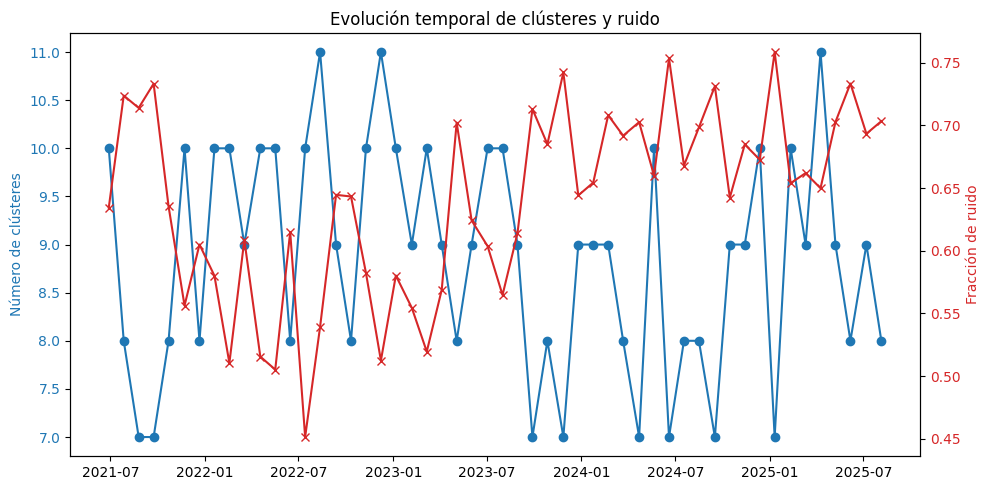

In [ ]:
# ============================================================
# Post-procesamiento y análisis de persistencia de clústeres
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------
# 1) Score de activos "core"
# ------------------------------
def core_assets(stability: pd.DataFrame, threshold: float = 0.6) -> pd.Series:
    """
    Devuelve un score por activo = proporción de co-pertenencia fuerte con otros activos.
    Un valor alto significa que el activo suele aparecer junto a los mismos pares.
    """
    scores = (stability >= threshold).mean(axis=1)
    return scores.sort_values(ascending=False)


# ------------------------------
# 2) Clústeres refinados (depurados por estabilidad)
# ------------------------------
def refined_clusters(windows, stability, threshold: float = 0.6, min_core: int = 2):
    """
    Devuelve los clústeres de la última ventana, pero filtrando:
    - Se eliminan miembros que no alcanzan el score de estabilidad.
    - Se descartan clústeres demasiado pequeños (< min_core).
    """
    if not windows:
        return {}

    last = windows[-1]   # última ventana
    labs = last.labels
    clusters = {}
    cid = 0

    # Score por activo
    scores = core_assets(stability, threshold=threshold)

    for c in sorted(set(labs)):
        if c < 0:  # ignorar ruido
            continue
        members = labs.index[labs == c].tolist()
        kept = [m for m in members if scores[m] >= threshold]
        if len(kept) >= min_core:
            clusters[cid] = kept
            cid += 1
    return clusters


# ------------------------------
# 3) Evolución temporal
# ------------------------------
def plot_cluster_evolution(windows):
    """
    Gráfico temporal con:
    - Número de clústeres detectados por ventana
    - Fracción de ruido
    """
    if not windows:
        print("No hay ventanas para graficar.")
        return

    dates = [w.end for w in windows]
    n_clusters = [w.quality["n_clusters"] for w in windows]
    noise_frac = [w.quality["noise_fraction"] for w in windows]

    fig, ax1 = plt.subplots(figsize=(10,5))

    # Número de clústeres
    ax1.plot(dates, n_clusters, marker="o", color="tab:blue", label="N° clústeres")
    ax1.set_ylabel("Número de clústeres", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Fracción de ruido
    ax2 = ax1.twinx()
    ax2.plot(dates, noise_frac, marker="x", color="tab:red", label="Frac. ruido")
    ax2.set_ylabel("Fracción de ruido", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Evolución temporal de clústeres y ruido")
    fig.tight_layout()
    plt.show()


# ============================================================
# Uso práctico
# ============================================================

# 1) Ranking de activos más estables
scores = core_assets(stability, threshold=0.6)
print("\nTop 10 activos más estables (core):")
print(scores.head(10))

# 2) Clústeres refinados de la última ventana
ref_clusters = refined_clusters(windows, stability, threshold=0.6, min_core=3)
print("\nClústeres refinados (última ventana, filtrados por estabilidad):")
for cid, members in ref_clusters.items():
    print(f"  C{cid}: n={len(members)} → {members[:12]}{' ...' if len(members) > 12 else ''}")

# 3) Evolución temporal de n° de clústeres y ruido
plot_cluster_evolution(windows)


## Cada número mide qué tan seguido ese activo aparece junto con los mismos pares (en los mismos clústeres) a lo largo de todas las ventanas temporales

In [ ]:
# ============================================================
# Selección de pares cointegrados (versión mejorada y consciente)
# ============================================================

!pip -q install statsmodels

import numpy as np
import pandas as pd
import itertools
from typing import Tuple, Optional, Dict
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# ===============================
# Funciones base de cointegración
# ===============================

def hedge_ratio(y: pd.Series, x: pd.Series) -> float:
    x = sm.add_constant(x.values, has_constant='add')
    model = sm.OLS(y.values, x, missing='drop').fit()
    return float(model.params[1])

def calc_half_life(spread: pd.Series) -> Optional[float]:
    s = spread.dropna()
    if len(s) < 30:
        return None
    y = s.diff().dropna()
    x = s.shift(1).reindex(y.index)
    x = sm.add_constant(x.values, has_constant='add')
    b = float(sm.OLS(y.values, x).fit().params[1])
    if b >= 0:
        return None
    return float(-np.log(2.0) / b)

def pair_metrics(prices: pd.DataFrame, a: str, b: str, lookback: int = 252) -> Dict:
    Px = prices[[a, b]].dropna()
    if len(Px) < max(60, lookback//3):
        return {}
    Px = Px.iloc[-lookback:]
    rx = np.log(Px).diff().dropna()
    if rx[a].std() == 0 or rx[b].std() == 0:
        return {}

    corr = float(rx[a].corr(rx[b]))

    try:
        pval = float(coint(Px[a].dropna(), Px[b].dropna(), trend='c', maxlag=5, autolag='AIC')[1])
    except Exception:
        pval = np.nan

    try:
        beta = hedge_ratio(np.log(Px[a]), np.log(Px[b]))
        spread = np.log(Px[a]) - beta * np.log(Px[b])
        hl = calc_half_life(spread)
        vol = float(spread.diff().std())
    except Exception:
        beta, hl, vol = np.nan, None, np.nan

    return {
        "corr": corr,
        "pval_coint": pval,
        "beta": beta,
        "half_life": hl,
        "spread_vol": vol,
        "n_obs": int(len(Px))
    }

# ============================================================
# Nuevo esquema de scoring (más consciente)
# ============================================================

def find_best_pairs(
    prices: pd.DataFrame,
    windows,
    stability: pd.DataFrame,
    stability_min: float = 0.60,
    pval_max: float = 0.05,
    half_life_opt: float = 30.0,
    half_life_tolerance: float = 25.0,
    lookback: int = 252,
    max_pairs_per_cluster: int = 30,
    max_output: int = 50
) -> pd.DataFrame:
    """
    Ranking de pares cointegrados con score multi-factor consciente:
      - Estabilidad
      - Correlación
      - Cointegración (p-val)
      - Half-life (óptimo configurable)
      - Volatilidad del spread
    """

    assert windows, "No hay ventanas calculadas."
    last = windows[-1]
    last_labels = last.labels.copy()
    last_labels = last_labels[last_labels >= 0]
    clusters = {c: sorted(last_labels.index[last_labels == c].tolist())
                for c in sorted(last_labels.unique())}

    tickers_present = set(last.embeddings.index)
    prices = prices.loc[:, prices.columns.intersection(tickers_present)].copy()

    common = sorted(list(tickers_present.intersection(stability.index).intersection(stability.columns)))
    S = stability.reindex(index=common, columns=common).copy()

    rows = []
    vols = []

    # --- 1) Calcular métricas por par ---
    for c, members in clusters.items():
        members = [m for m in members if m in S.index]
        if len(members) < 2:
            continue

        combos = list(itertools.combinations(members, 2))
        if len(combos) > max_pairs_per_cluster:
            combos.sort(key=lambda ab: S.loc[ab[0], ab[1]], reverse=True)
            combos = combos[:max_pairs_per_cluster]

        for a, b in combos:
            stab = float(S.loc[a, b]) if (a in S.index and b in S.columns) else np.nan
            if np.isnan(stab) or stab < stability_min:
                continue

            m = pair_metrics(prices, a, b, lookback=lookback)
            if not m or np.isnan(m.get("corr", np.nan)):
                continue

            m["stability"] = stab
            m["cluster"] = c
            m["A"], m["B"] = a, b
            rows.append(m)
            if not np.isnan(m["spread_vol"]):
                vols.append(m["spread_vol"])

    if not rows:
        print("No se encontraron pares válidos tras el cálculo de métricas.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    max_vol = np.nanpercentile(vols, 90) if vols else 1.0

    # --- 2) Normalizar métricas ---
    df["score_stab"] = df["stability"].clip(0, 1)
    df["score_corr"] = (df["corr"] + 1) / 2
    df["score_pval"] = 1 - np.minimum(df["pval_coint"] / pval_max, 1.0)
    df["score_hl"] = 1 - np.minimum(np.abs(df["half_life"] - half_life_opt) / half_life_tolerance, 1.0)
    df["score_vol"] = np.minimum(df["spread_vol"] / max_vol, 1.0)

    df["score_hl"] = df["score_hl"].fillna(0.0)
    df["score_pval"] = df["score_pval"].fillna(0.0)
    df["score_vol"] = df["score_vol"].fillna(0.0)

    # --- 3) Score final ponderado (ajustable) ---
    df["score"] = (
        0.35 * df["score_stab"] +
        0.25 * df["score_corr"] +
        0.20 * df["score_pval"] +
        0.10 * df["score_hl"] +
        0.10 * df["score_vol"]
    )

    # --- 4) Filtros finales ---
    df = df[df["score_stab"] >= stability_min]
    df = df[df["pval_coint"] <= pval_max]
    df = df[df["corr"] > 0]
    df = df.sort_values("score", ascending=False).reset_index(drop=True)

    df = df.head(max_output)
    from IPython.display import display
    print(f"✓ Ranking generado: {len(df)} pares (score consciente)\n")
    display(df[[
        "cluster", "A", "B", "score", "stability", "corr",
        "pval_coint", "half_life", "spread_vol", "beta"
    ]])

    return df


# ============================================================
# Ejecución práctica
# ============================================================

prices_df_for_pairs = prices_wide if 'prices_wide' in globals() else datos
best_pairs = find_best_pairs(
    prices=prices_df_for_pairs,
    windows=windows,
    stability=stability,
    stability_min=0.60,
    pval_max=0.05,
    half_life_opt=30,
    half_life_tolerance=25,
    lookback=252,
    max_pairs_per_cluster=30,
    max_output=50
)


✓ Ranking generado: 7 pares (score consciente)



,cluster,A,B,score,stability,corr,pval_coint,half_life,spread_vol,beta
0,6,KEY,RF,0.774264,0.961538,0.904414,0.011331,3.680286,0.009218,0.922626
1,6,KEY,PNC,0.741454,0.942308,0.894603,0.019910,6.572496,0.009868,1.004535
2,2,AEE,AEP,0.720385,1.000000,0.643021,0.025239,10.793550,0.008766,0.723928
3,4,CPT,ESS,0.681887,0.980769,0.879593,0.034932,7.687080,0.006688,0.825795
4,7,AFL,L,0.675098,0.615385,0.769278,0.010942,5.942391,0.016092,-0.203116
5,4,ESS,UDR,0.643515,0.980769,0.903609,0.048597,10.440659,0.007154,0.879770
6,2,DUK,SO,0.640471,1.000000,0.843105,0.048862,11.517252,0.006036,0.885402


In [ ]:
def calc_half_life_rolling(spread: pd.Series, window: int = 60) -> Optional[float]:
    """
    Calcula el half-life del spread respecto a su media móvil.
    Devuelve None si no hay reversión clara.
    """
    s = spread.dropna()
    if len(s) < window + 10:
        return None

    ma = s.rolling(window=window).mean()
    residuals = s - ma
    residuals = residuals.dropna()

    y = residuals.diff().dropna()
    x = residuals.shift(1).reindex(y.index)
    x = sm.add_constant(x.values, has_constant='add')
    try:
        beta = float(sm.OLS(y.values, x).fit().params[1])
        if beta >= 0:
            return None
        return float(-np.log(2.0) / beta)
    except:
        return None


In [ ]:
from itertools import combinations

def build_pair_table(prices: pd.DataFrame, stability: pd.DataFrame,
                     lookback: int = 252, hl_win: int = 60) -> pd.DataFrame:
    """
    Genera tabla de pares con métricas: beta, half-life, spread_vol, estabilidad.
    """
    tickers = list(stability.index)
    combos = list(combinations(tickers, 2))
    results = []

    for a, b in combos:
        if a not in prices.columns or b not in prices.columns:
            continue

        Px = prices[[a, b]].dropna().iloc[-lookback:]
        if len(Px) < max(60, lookback // 3):
            continue

        try:
            log_pa, log_pb = np.log(Px[a]), np.log(Px[b])
            beta = hedge_ratio(log_pa, log_pb)
            spread = log_pa - beta * log_pb
            hl = calc_half_life_rolling(spread, window=hl_win)
            vol = spread.diff().std()
            stab = stability.loc[a, b] if a in stability.index and b in stability.columns else np.nan

            results.append({
                "A": a,
                "B": b,
                "beta": beta,
                "half_life_days": hl,
                "spread_vol": vol,
                "stability_ab": stab,
                "hl_ref": f"rolling({hl_win})",
                "spread_def": "log(A) - β·log(B)"
            })
        except:
            continue

    df = pd.DataFrame(results)
    df = df.dropna(subset=["half_life_days", "beta", "spread_vol", "stability_ab"])
    df = df.sort_values(["stability_ab", "half_life_days"], ascending=[False, True]).reset_index(drop=True)
    return df


In [ ]:
import yfinance as yf

def fetch_sector_info(tickers: list) -> pd.DataFrame:
    """Obtiene el sector para cada ticker."""
    data = {}
    for t in tickers:
        try:
            info = yf.Ticker(t).info
            data[t] = info.get("sector", None)
        except:
            data[t] = None
    return pd.DataFrame.from_dict(data, orient="index", columns=["sector"])

def filter_diff_sector(df: pd.DataFrame, sectors: pd.DataFrame) -> pd.DataFrame:
    """Filtra solo pares con sectores distintos."""
    df = df.copy()
    df["sector_A"] = df["A"].map(sectors["sector"])
    df["sector_B"] = df["B"].map(sectors["sector"])
    return df[df["sector_A"] != df["sector_B"]]


In [ ]:
# Filtrar por activos core más estables
core = core_assets(stability, threshold=0.6).index.tolist()

# Crear tabla de pares con métricas
pairs_df = build_pair_table(
    prices=prices_wide[core],
    stability=stability.loc[core, core],
    lookback=252,
    hl_win=60
)
print(f"✓ Tabla generada: {len(pairs_df)} pares")
display(pairs_df.head(20))


✓ Tabla generada: 125240 pares


,A,B,beta,half_life_days,spread_vol,stability_ab,hl_ref,spread_def
0,SLB,DVN,0.889171,6.404800,0.015940,1.0,rolling(60),log(A) - β·log(B)
1,COP,HAL,0.469734,6.647486,0.013658,1.0,rolling(60),log(A) - β·log(B)
2,HAL,BKR,0.524453,7.134870,0.018792,1.0,rolling(60),log(A) - β·log(B)
3,COP,BKR,0.283305,7.224652,0.017581,1.0,rolling(60),log(A) - β·log(B)
4,COP,CVX,0.929576,7.353448,0.012802,1.0,rolling(60),log(A) - β·log(B)
5,COP,VLO,0.411157,7.469068,0.016366,1.0,rolling(60),log(A) - β·log(B)
6,COP,MPC,0.132338,7.919659,0.019333,1.0,rolling(60),log(A) - β·log(B)
7,HAL,OXY,1.476092,7.952385,0.019297,1.0,rolling(60),log(A) - β·log(B)
8,APA,OXY,1.528715,7.969743,0.018262,1.0,rolling(60),log(A) - β·log(B)
9,AEP,DUK,1.278979,8.109633,0.009010,1.0,rolling(60),log(A) - β·log(B)


In [ ]:
# Filtro opcional por sector distinto
all_tickers = sorted(set(pairs_df["A"]).union(pairs_df["B"]))
sector_df = fetch_sector_info(all_tickers)

# Aplicar filtro y mostrar
pairs_filtered = filter_diff_sector(pairs_df, sector_df)
print(f"✓ Pares con sector distinto: {len(pairs_filtered)}")
display(pairs_filtered.head(20))


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BRK_B"}}}


✓ Pares con sector distinto: 111652


,A,B,beta,half_life_days,spread_vol,stability_ab,hl_ref,spread_def,sector_A,sector_B
985,OKE,CF,-0.066922,6.778410,0.021020,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
986,FANG,CF,0.318364,7.435369,0.023198,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
988,COP,CF,0.137985,8.418073,0.020330,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
994,HAL,CF,0.116590,10.268058,0.025001,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
996,SLB,CF,-0.060577,10.383503,0.023329,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
997,DVN,CF,0.191586,11.012437,0.024345,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
999,MPC,CF,0.802006,11.534945,0.022010,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
1000,XOM,CF,0.084702,11.967123,0.014235,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
1001,OXY,CF,0.239864,12.218065,0.020559,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials
1004,CTRA,CF,-0.016367,12.599684,0.019195,0.673077,rolling(60),log(A) - β·log(B),Energy,Basic Materials


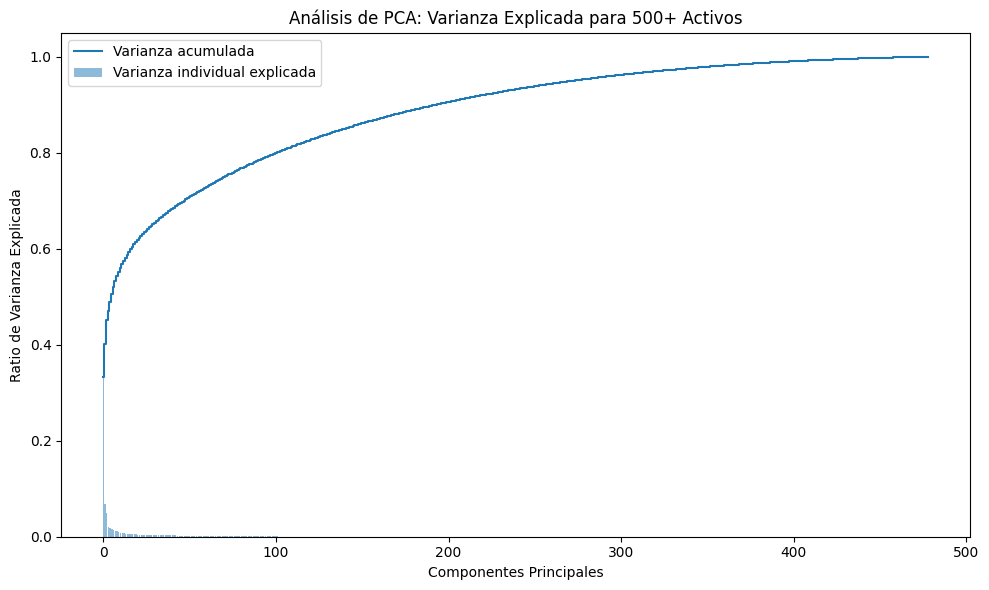

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Usamos los resultados del PCA almacenados en el diccionario 'meta'
exp_var_pca = meta["explained_var_ratio"]
cum_sum_eigenvalues = meta["cumulative_explained_var_ratio"]

plt.figure(figsize=(10, 6))
plt.bar(range(0, len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Varianza individual explicada')
plt.step(range(0, len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid', label='Varianza acumulada')
plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('Análisis de PCA: Varianza Explicada para 500+ Activos')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('pca_variance.png') # Se guarda como imagen
plt.show()

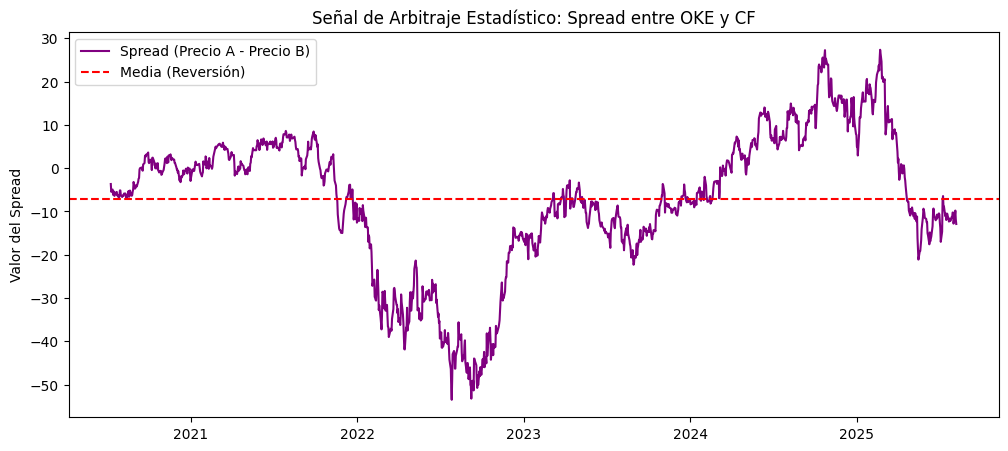

In [ ]:
# Elige dos activos que el modelo identificó en el mismo cluster
asset1 = 'OKE' # Ejemplo
asset2 = 'CF' # Ejemplo

# Calcula el spread (simplificado)
spread = prices_wide[asset1] - prices_wide[asset2]
mean_spread = spread.mean()

plt.figure(figsize=(12, 5))
plt.plot(spread, label='Spread (Precio A - Precio B)', color='purple')
plt.axhline(mean_spread, color='red', linestyle='--', label='Media (Reversión)')
plt.title(f'Señal de Arbitraje Estadístico: Spread entre {asset1} y {asset2}')
plt.ylabel('Valor del Spread')
plt.legend()
plt.savefig('trading_signal.png') # Se guarda como imagen
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ============================================================
# 1) Selección de pares para backtest
# ============================================================

def select_pairs_for_backtest(pairs_table: pd.DataFrame,
                              top_n: int = 5,
                              min_stability: float = 0.75,
                              min_half_life: float = 5,
                              max_half_life: float = 25) -> pd.DataFrame:
    df = pairs_table.copy()

    df = df.dropna(subset=["A", "B", "beta", "half_life_days", "stability_ab"])
    df = df[
        (df["stability_ab"] >= min_stability) &
        (df["half_life_days"] >= min_half_life) &
        (df["half_life_days"] <= max_half_life)
    ].copy()

    df = df.sort_values(
        ["stability_ab", "half_life_days"],
        ascending=[False, True]
    ).head(top_n).reset_index(drop=True)

    return df


# ============================================================
# 2) Backtest de un par
# ============================================================

def backtest_pair_strategy(prices: pd.DataFrame,
                           asset_a: str,
                           asset_b: str,
                           lookback: int = 252,
                           entry_z: float = 2.5,
                           exit_z: float = 0.0,
                           stop_z: float = 3.5,
                           rebalance_every: int = 21,
                           cost_bps: float = 5.0,
                           max_holding_mult: float = 2.0) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Long spread cuando z < -entry_z
    Short spread cuando z > entry_z

    Spread = log(A) - beta * log(B)
    Retorno diario del par = position * (rA - beta*rB)/(1+|beta|)
    """

    df = prices[[asset_a, asset_b]].dropna().copy()
    df.columns = ["A", "B"]

    if len(df) < lookback + 30:
        return pd.DataFrame(), pd.DataFrame()

    logp = np.log(df)
    rets = logp.diff().fillna(0.0)

    dates = df.index
    out = []

    position = 0       # 1 = long spread, -1 = short spread, 0 = flat
    holding_days = 0
    trade_id = 0
    current_trade = None

    beta_t = np.nan
    mu_t = np.nan
    sigma_t = np.nan
    hl_t = np.nan

    for t in range(lookback, len(df) - 1):
        train = logp.iloc[t - lookback:t]

        if (t == lookback) or ((t - lookback) % rebalance_every == 0):
            try:
                x = sm.add_constant(train["B"].values, has_constant="add")
                beta_t = float(sm.OLS(train["A"].values, x).fit().params[1])
            except:
                beta_t = np.nan

            spread_train = train["A"] - beta_t * train["B"]
            mu_t = float(spread_train.mean())
            sigma_t = float(spread_train.std(ddof=1))

            # half-life rolling simple
            s = spread_train.dropna()
            if len(s) >= 30:
                y = s.diff().dropna()
                x = s.shift(1).reindex(y.index)
                x = sm.add_constant(x.values, has_constant="add")
                try:
                    b = float(sm.OLS(y.values, x).fit().params[1])
                    hl_t = float(-np.log(2.0) / b) if b < 0 else np.nan
                except:
                    hl_t = np.nan
            else:
                hl_t = np.nan

        if np.isnan(beta_t) or np.isnan(mu_t) or np.isnan(sigma_t) or sigma_t == 0:
            continue

        spread_t = logp["A"].iloc[t] - beta_t * logp["B"].iloc[t]
        z_t = (spread_t - mu_t) / sigma_t

        prev_position = position

        # Reglas de entrada/salida
        max_holding = int(max(5, (hl_t if pd.notna(hl_t) else 10) * max_holding_mult))

        if position == 0:
            if z_t > entry_z:
                position = -1
                holding_days = 0
                trade_id += 1
                current_trade = {
                    "trade_id": trade_id,
                    "entry_date": dates[t],
                    "pair": f"{asset_a}-{asset_b}",
                    "direction": "short_spread",
                    "entry_z": z_t
                }
            elif z_t < -entry_z:
                position = 1
                holding_days = 0
                trade_id += 1
                current_trade = {
                    "trade_id": trade_id,
                    "entry_date": dates[t],
                    "pair": f"{asset_a}-{asset_b}",
                    "direction": "long_spread",
                    "entry_z": z_t
                }

        else:
            holding_days += 1

            exit_condition = (
                (position == 1 and z_t >= -exit_z) or
                (position == -1 and z_t <= exit_z) or
                (abs(z_t) >= stop_z) or
                (holding_days >= max_holding)
            )

            if exit_condition:
                position = 0
                if current_trade is not None:
                    current_trade["exit_date"] = dates[t]
                    current_trade["exit_z"] = z_t
                    current_trade["holding_days"] = holding_days

        # retorno del día siguiente usando posición determinada hoy
        pair_ret_next = position * (
            rets["A"].iloc[t + 1] - beta_t * rets["B"].iloc[t + 1]
        ) / (1.0 + abs(beta_t))

        # costos por cambio de posición
        turnover = abs(position - prev_position)
        cost = turnover * (cost_bps / 10000.0)
        net_ret = pair_ret_next - cost

        out.append({
            "date": dates[t + 1],
            "pair": f"{asset_a}-{asset_b}",
            "position": position,
            "beta": beta_t,
            "zscore": z_t,
            "half_life": hl_t,
            "gross_return": pair_ret_next,
            "net_return": net_ret,
            "turnover": turnover
        })

        # cerrar trade en log cuando se sale
        if prev_position != 0 and position == 0 and current_trade is not None:
            trade_slice = [x for x in out if x["pair"] == f"{asset_a}-{asset_b}" and x["date"] > current_trade["entry_date"]]
            if len(trade_slice) > 0:
                trade_ret = np.prod([1 + x["net_return"] for x in trade_slice]) - 1
            else:
                trade_ret = 0.0
            current_trade["trade_return"] = trade_ret
            if "trades_log" not in locals():
                trades_log = []
            trades_log.append(current_trade)
            current_trade = None

    bt = pd.DataFrame(out).set_index("date")
    trades = pd.DataFrame(locals().get("trades_log", []))

    return bt, trades


# ============================================================
# 3) Backtest portfolio de múltiples pares
# ============================================================

def backtest_pairs_portfolio(prices: pd.DataFrame,
                             selected_pairs: pd.DataFrame,
                             lookback: int = 252,
                             entry_z: float = 2.5,
                             exit_z: float = 0.0,
                             stop_z: float = 3.5,
                             rebalance_every: int = 21,
                             cost_bps: float = 5.0,
                             max_holding_mult: float = 2.0):
    pair_returns = []
    pair_trades = []

    for _, row in selected_pairs.iterrows():
        a, b = row["A"], row["B"]
        bt, trades = backtest_pair_strategy(
            prices=prices,
            asset_a=a,
            asset_b=b,
            lookback=lookback,
            entry_z=entry_z,
            exit_z=exit_z,
            stop_z=stop_z,
            rebalance_every=rebalance_every,
            cost_bps=cost_bps,
            max_holding_mult=max_holding_mult
        )

        if not bt.empty:
            pair_returns.append(bt[["pair", "net_return", "gross_return", "position", "turnover"]].copy())

        if not trades.empty:
            pair_trades.append(trades)

    if not pair_returns:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    all_returns = pd.concat(pair_returns).reset_index()
    portfolio = (
        all_returns.groupby("date")
        .agg(
            portfolio_net_return=("net_return", "mean"),
            portfolio_gross_return=("gross_return", "mean"),
            active_pairs=("pair", "nunique"),
            avg_turnover=("turnover", "mean")
        )
        .sort_index()
    )

    all_trades = pd.concat(pair_trades, ignore_index=True) if pair_trades else pd.DataFrame()

    return portfolio, all_returns, all_trades


# ============================================================
# 4) Métricas
# ============================================================

def compute_performance_metrics(return_series: pd.Series, trades: pd.DataFrame | None = None) -> pd.Series:
    r = return_series.dropna().copy()
    if len(r) == 0:
        return pd.Series(dtype=float)

    equity = (1 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1

    ann_return = equity.iloc[-1] ** (252 / len(r)) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    sharpe = (r.mean() / r.std(ddof=1)) * np.sqrt(252) if r.std(ddof=1) > 0 else np.nan
    max_dd = drawdown.min()
    hit_rate = (r > 0).mean()

    out = {
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Daily Hit Rate": hit_rate,
        "Total Days": len(r),
        "Cumulative Return": equity.iloc[-1] - 1
    }

    if trades is not None and not trades.empty and "trade_return" in trades.columns:
        out["Number of Trades"] = len(trades)
        out["Trade Win Rate"] = (trades["trade_return"] > 0).mean()
        out["Avg Trade Return"] = trades["trade_return"].mean()
        out["Avg Holding Period"] = trades["holding_days"].mean()

    return pd.Series(out)

In [ ]:
# ============================================================
# 5) Ejecutar selección y backtest
# ============================================================

candidate_pairs = select_pairs_for_backtest(
    pairs_table=pairs_df if "pairs_df" in globals() else pairs_df,
    top_n=5,
    min_stability=0.75,
    min_half_life=5,
    max_half_life=25
)

display(candidate_pairs)

portfolio_bt, pair_level_bt, trades_bt = backtest_pairs_portfolio(
    prices=prices_wide,
    selected_pairs=candidate_pairs,
    lookback=252,
    entry_z=2.5,
    exit_z=0.0,
    stop_z=3.5,
    rebalance_every=21,
    cost_bps=5.0,
    max_holding_mult=2.0
)

display(portfolio_bt.head())
display(trades_bt.head())

metrics = compute_performance_metrics(
    portfolio_bt["portfolio_net_return"],
    trades_bt
)

print("\n=== PERFORMANCE METRICS ===")
display(metrics)

,A,B,beta,half_life_days,spread_vol,stability_ab,hl_ref,spread_def
0,SLB,DVN,0.889171,6.404800,0.015940,1.0,rolling(60),log(A) - β·log(B)
1,COP,HAL,0.469734,6.647486,0.013658,1.0,rolling(60),log(A) - β·log(B)
2,HAL,BKR,0.524453,7.134870,0.018792,1.0,rolling(60),log(A) - β·log(B)
3,COP,BKR,0.283305,7.224652,0.017581,1.0,rolling(60),log(A) - β·log(B)
4,COP,CVX,0.929576,7.353448,0.012802,1.0,rolling(60),log(A) - β·log(B)


,portfolio_net_return,portfolio_gross_return,active_pairs,avg_turnover
date,,,,
2021-06-29,0.0,0.0,3,0.0
2021-06-30,0.0,0.0,3,0.0
2021-07-01,0.0,0.0,3,0.0
2021-07-02,0.0,0.0,3,0.0
2021-07-05,0.0,0.0,3,0.0


,trade_id,entry_date,pair,direction,entry_z,exit_date,exit_z,holding_days,trade_return
0,1,2021-07-16,SLB-DVN,long_spread,-2.795513,2021-08-18,-2.688154,23,-0.014664
1,2,2021-08-19,SLB-DVN,long_spread,-2.780480,2021-08-23,-3.740485,2,-0.031984
2,3,2021-08-24,SLB-DVN,long_spread,-3.415053,2021-09-03,-3.674076,8,-0.039155
3,4,2021-09-06,SLB-DVN,long_spread,-3.681646,2021-10-15,-1.809461,29,0.014656
4,5,2021-10-20,SLB-DVN,long_spread,-2.670092,2021-12-08,0.270539,35,0.070013



=== PERFORMANCE METRICS ===


,0
Annualized Return,0.015030
Annualized Volatility,0.066040
Sharpe Ratio,0.258919
Max Drawdown,-0.075050
Daily Hit Rate,0.386766
Total Days,1073.000000
Cumulative Return,0.065583
Number of Trades,98.000000
Trade Win Rate,0.408163
Avg Trade Return,0.002848


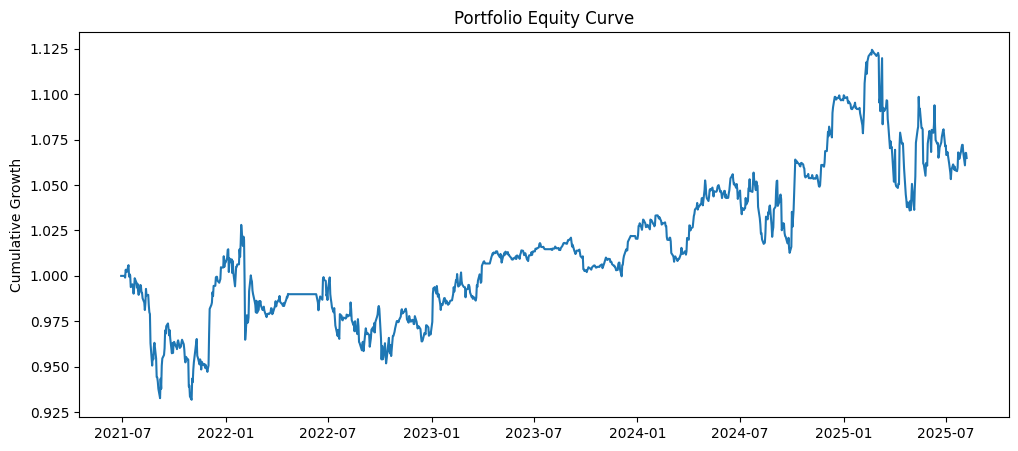

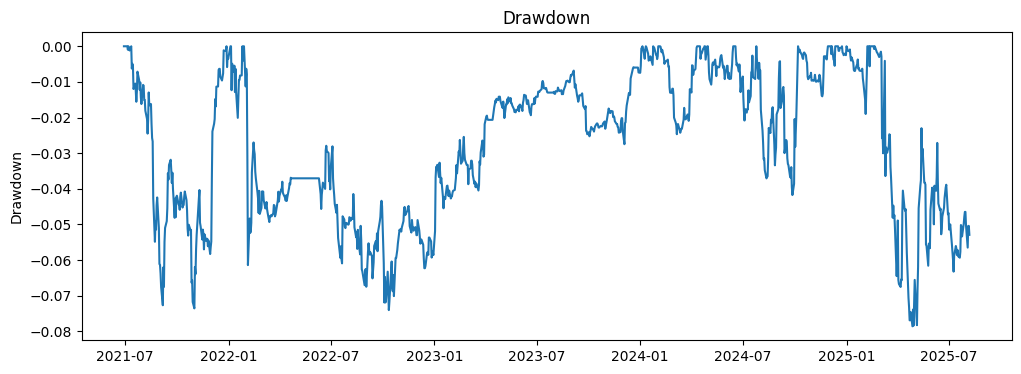

In [ ]:
import matplotlib.pyplot as plt

equity = (1 + portfolio_bt["portfolio_net_return"].fillna(0)).cumprod()
dd = equity / equity.cummax() - 1

plt.figure(figsize=(12,5))
plt.plot(equity.index, equity.values)
plt.title("Portfolio Equity Curve")
plt.ylabel("Cumulative Growth")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(dd.index, dd.values)
plt.title("Drawdown")
plt.ylabel("Drawdown")
plt.show()

In [ ]:
# PARES MAS RELEVANTES

pair_summary = (
    pair_level_bt.groupby("pair")
    .agg(
        mean_daily_return=("net_return", "mean"),
        vol_daily=("net_return", "std"),
        cumulative_return=("net_return", lambda x: (1 + x).prod() - 1),
        days=("net_return", "count")
    )
)

pair_summary["sharpe_proxy"] = (
    pair_summary["mean_daily_return"] / pair_summary["vol_daily"]
) * (252 ** 0.5)

pair_summary = pair_summary.sort_values("cumulative_return", ascending=False)
display(pair_summary)

,mean_daily_return,vol_daily,cumulative_return,days,sharpe_proxy
pair,,,,,
COP-BKR,0.000285,0.007909,0.203140,727,0.572979
COP-HAL,0.000178,0.004193,0.198944,1073,0.673382
COP-CVX,0.000176,0.003999,0.197577,1073,0.698766
SLB-DVN,0.000066,0.007918,0.037533,1073,0.131604
HAL-BKR,-0.000424,0.010480,-0.294715,727,-0.642583


In [ ]:
# SOLO PARES RELEVANTES

best_pair_names = ["COP-CVX", "COP-HAL", "COP-BKR"]

In [ ]:
candidate_pairs_best = candidate_pairs[
    candidate_pairs.apply(lambda row: f"{row['A']}-{row['B']}" in best_pair_names, axis=1)
].copy()

portfolio_bt_best, pair_level_bt_best, trades_bt_best = backtest_pairs_portfolio(
    prices=prices_wide,
    selected_pairs=candidate_pairs_best,
    lookback=252,
    entry_z=2.5,
    exit_z=0.0,
    stop_z=3.5,
    rebalance_every=21,
    cost_bps=5.0,
    max_holding_mult=2.0
)

metrics_best = compute_performance_metrics(
    portfolio_bt_best["portfolio_net_return"],
    trades_bt_best
)

display(metrics_best)

,0
Annualized Return,0.043304
Annualized Volatility,0.057997
Sharpe Ratio,0.759898
Max Drawdown,-0.076365
Daily Hit Rate,0.296365
Total Days,1073.000000
Cumulative Return,0.197822
Number of Trades,65.000000
Trade Win Rate,0.430769
Avg Trade Return,0.009178


In [ ]:
import numpy as np
import pandas as pd

def rolling_select_and_backtest(
    prices: pd.DataFrame,
    candidate_pairs: pd.DataFrame,
    lookback_window: int = 252,
    rebalance_window: int = 63,
    top_k: int = 3,
    entry_z: float = 2.5,
    exit_z: float = 0.0,
    stop_z: float = 3.5,
    rebalance_every: int = 21,
    cost_bps: float = 5.0,
    max_holding_mult: float = 2.0
):
    """
    En cada fecha de rebalance:
    1) Usa el histórico anterior (lookback_window) para evaluar todos los pares
    2) Selecciona los top_k por cumulative return
    3) Opera SOLO el siguiente bloque out-of-sample (rebalance_window)
    """

    prices = prices.copy().sort_index()
    dates = prices.index

    portfolio_chunks = []
    all_pair_chunks = []
    all_trade_chunks = []
    selection_log = []

    t = lookback_window

    while t + rebalance_window < len(dates):
        train_start = t - lookback_window
        train_end = t
        test_end = t + rebalance_window

        train_prices = prices.iloc[train_start:train_end].copy()
        test_prices = prices.iloc[train_start:test_end].copy()
        # incluimos histórico para que el modelo tenga lookback suficiente al entrar al periodo test

        # ----------------------------------------------------
        # 1) Backtest in-sample por par para rankear
        # ----------------------------------------------------
        train_pair_results = []

        for _, row in candidate_pairs.iterrows():
            a, b = row["A"], row["B"]

            bt_train, trades_train = backtest_pair_strategy(
                prices=train_prices,
                asset_a=a,
                asset_b=b,
                lookback=min(lookback_window, max(60, len(train_prices) - 30)),
                entry_z=entry_z,
                exit_z=exit_z,
                stop_z=stop_z,
                rebalance_every=rebalance_every,
                cost_bps=cost_bps,
                max_holding_mult=max_holding_mult
            )

            if not bt_train.empty:
                cumret = (1 + bt_train["net_return"]).prod() - 1
                mean_ret = bt_train["net_return"].mean()
                vol_ret = bt_train["net_return"].std(ddof=1)
                sharpe_proxy = (mean_ret / vol_ret) * np.sqrt(252) if vol_ret > 0 else np.nan

                train_pair_results.append({
                    "pair": f"{a}-{b}",
                    "A": a,
                    "B": b,
                    "train_cumret": cumret,
                    "train_sharpe_proxy": sharpe_proxy,
                    "train_days": len(bt_train)
                })

        if len(train_pair_results) == 0:
            t += rebalance_window
            continue

        train_pair_df = pd.DataFrame(train_pair_results).sort_values(
            ["train_cumret", "train_sharpe_proxy"],
            ascending=[False, False]
        )

        selected = train_pair_df.head(top_k).copy()

        selection_log.append({
            "rebalance_date": dates[t],
            "selected_pairs": list(selected["pair"].values)
        })

        # ----------------------------------------------------
        # 2) Operar out-of-sample SOLO en el siguiente bloque
        # ----------------------------------------------------
        period_start_date = dates[t]
        period_end_date = dates[test_end - 1]

        for _, row in selected.iterrows():
            a, b = row["A"], row["B"]

            bt_full, trades_full = backtest_pair_strategy(
                prices=test_prices,
                asset_a=a,
                asset_b=b,
                lookback=min(lookback_window, max(60, len(test_prices) - 30)),
                entry_z=entry_z,
                exit_z=exit_z,
                stop_z=stop_z,
                rebalance_every=rebalance_every,
                cost_bps=cost_bps,
                max_holding_mult=max_holding_mult
            )

            if bt_full.empty:
                continue

            bt_oos = bt_full.loc[(bt_full.index >= period_start_date) & (bt_full.index <= period_end_date)].copy()
            if bt_oos.empty:
                continue

            bt_oos["rebalance_date"] = dates[t]

            all_pair_chunks.append(bt_oos.reset_index())

            if not trades_full.empty:
                trades_oos = trades_full[
                    (trades_full["entry_date"] >= period_start_date) &
                    (trades_full["entry_date"] <= period_end_date)
                ].copy()

                if not trades_oos.empty:
                    trades_oos["rebalance_date"] = dates[t]
                    all_trade_chunks.append(trades_oos)

        t += rebalance_window

    if len(all_pair_chunks) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    all_pair_bt = pd.concat(all_pair_chunks, ignore_index=True)
    all_pair_bt["date"] = pd.to_datetime(all_pair_bt["date"])
    all_pair_bt = all_pair_bt.sort_values(["date", "pair"]).copy()

    rolling_portfolio = (
        all_pair_bt.groupby("date")
        .agg(
            portfolio_net_return=("net_return", "mean"),
            portfolio_gross_return=("gross_return", "mean"),
            active_pairs=("pair", "nunique"),
            avg_turnover=("turnover", "mean")
        )
        .sort_index()
    )

    rolling_trades = pd.concat(all_trade_chunks, ignore_index=True) if len(all_trade_chunks) > 0 else pd.DataFrame()
    selection_log_df = pd.DataFrame(selection_log)

    return rolling_portfolio, all_pair_bt, rolling_trades, selection_log_df

In [ ]:
rolling_portfolio_bt, rolling_pair_bt, rolling_trades_bt, selection_log = rolling_select_and_backtest(
    prices=prices_wide,
    candidate_pairs=candidate_pairs_best,   # usa los 3 buenos que ya descubriste
    lookback_window=252,
    rebalance_window=63,
    top_k=3,
    entry_z=2.5,
    exit_z=0.0,
    stop_z=3.5,
    rebalance_every=21,
    cost_bps=5.0,
    max_holding_mult=2.0
)

display(selection_log.head())
display(rolling_portfolio_bt.head())
display(rolling_trades_bt.head())

rolling_metrics = compute_performance_metrics(
    rolling_portfolio_bt["portfolio_net_return"],
    rolling_trades_bt
)

print("\n=== ROLLING PERFORMANCE METRICS ===")
display(rolling_metrics)

,rebalance_date,selected_pairs
0,2021-06-28,"[COP-CVX, COP-HAL]"
1,2021-09-23,"[COP-HAL, COP-CVX]"
2,2021-12-21,"[COP-HAL, COP-CVX]"
3,2022-03-18,"[COP-CVX, COP-HAL]"
4,2022-06-15,"[COP-HAL, COP-CVX]"


,portfolio_net_return,portfolio_gross_return,active_pairs,avg_turnover
date,,,,
2021-06-29,0.0,0.0,2,0.0
2021-06-30,0.0,0.0,2,0.0
2021-07-01,0.0,0.0,2,0.0
2021-07-02,0.0,0.0,2,0.0
2021-07-05,0.0,0.0,2,0.0


,trade_id,entry_date,pair,direction,entry_z,exit_date,exit_z,holding_days,trade_return,rebalance_date
0,1,2021-08-12,COP-CVX,short_spread,2.533381,2021-08-20,4.006250,6,-0.031972,2021-06-28
1,2,2021-08-23,COP-CVX,short_spread,4.078261,2021-08-24,3.810392,1,0.004697,2021-06-28
2,3,2021-08-25,COP-CVX,short_spread,3.075004,2021-08-31,3.500397,4,-0.011958,2021-06-28
3,4,2021-09-01,COP-CVX,short_spread,3.346704,2021-09-02,3.554424,1,-0.006352,2021-06-28
4,5,2021-09-03,COP-CVX,short_spread,3.348314,2021-09-06,3.574301,1,-0.006823,2021-06-28



=== ROLLING PERFORMANCE METRICS ===


,0
Annualized Return,0.032638
Annualized Volatility,0.048301
Sharpe Ratio,0.689017
Max Drawdown,-0.074888
Daily Hit Rate,0.211575
Total Days,1054.000000
Cumulative Return,0.143768
Number of Trades,61.000000
Trade Win Rate,0.311475
Avg Trade Return,0.001553


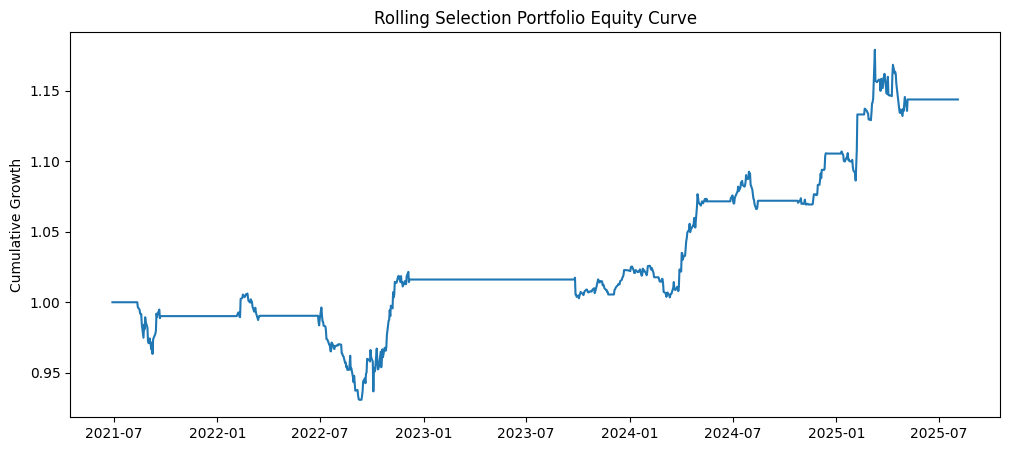

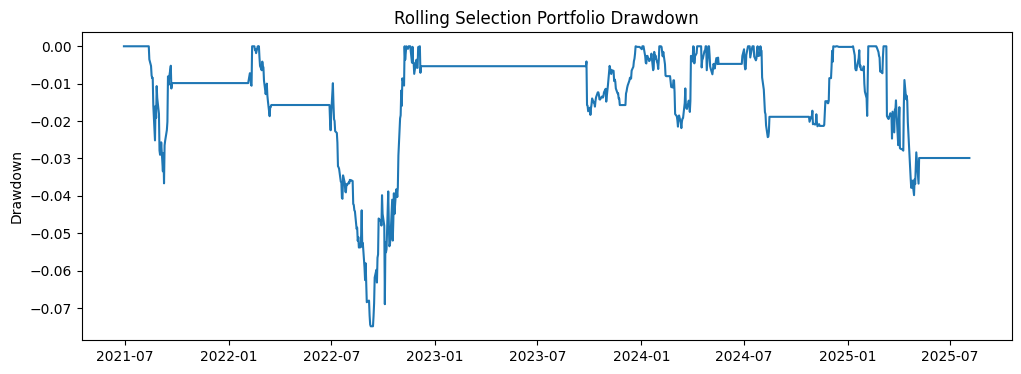

In [ ]:
import matplotlib.pyplot as plt

rolling_equity = (1 + rolling_portfolio_bt["portfolio_net_return"].fillna(0)).cumprod()
rolling_dd = rolling_equity / rolling_equity.cummax() - 1

plt.figure(figsize=(12,5))
plt.plot(rolling_equity.index, rolling_equity.values)
plt.title("Rolling Selection Portfolio Equity Curve")
plt.ylabel("Cumulative Growth")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_dd.index, rolling_dd.values)
plt.title("Rolling Selection Portfolio Drawdown")
plt.ylabel("Drawdown")
plt.show()